# AIN 214 PA3 on Data Prepocessing and Regression

# THE STUDENT INFO
## Student Name: Ibrahim Buyukkafes
## Student ID: b2210765039

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
path_to_dataset = 'housing.csv'
housing_df = pd.read_csv(path_to_dataset)

# We will deal with the famous California Housing Prices dataset from Kaggle. [1]

# 1. Data Preprocessing (50 Pts)

## 1.1. Explaratory Data Analysis (10 Pts)

* Check for missing values
* Visualize the features with any relevant plots to understand the distribution of data
* Visualize the target variable with respect to the features 
* Visualize the correlation between the features using a heatmap
* Comment on any findings

In [2]:
missing_values = housing_df.isnull().sum()
missing_values

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

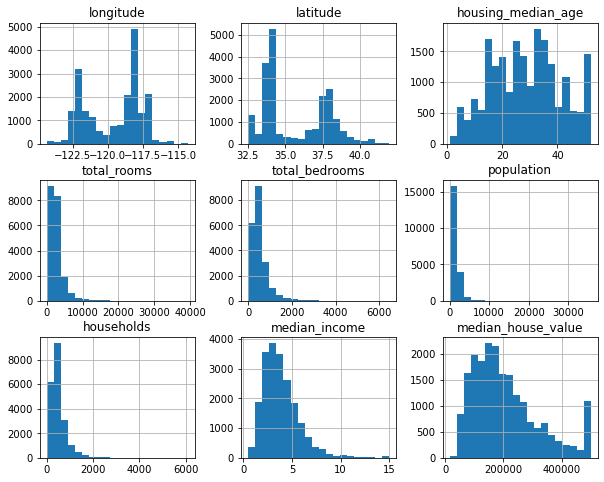

In [3]:
housing_df.hist(bins=20, figsize=(10,8))
plt.show()

In [4]:
#We see in these graphs where the data reaches its maximum values.
#For example, the longitude reached its maximum value between -120.0 and -117.5, and this value remained below 5000.
#For example, the latitude reached its maximum value between 32.5 and 35.0, and this value remained over 5000.
#We can access comments like this.

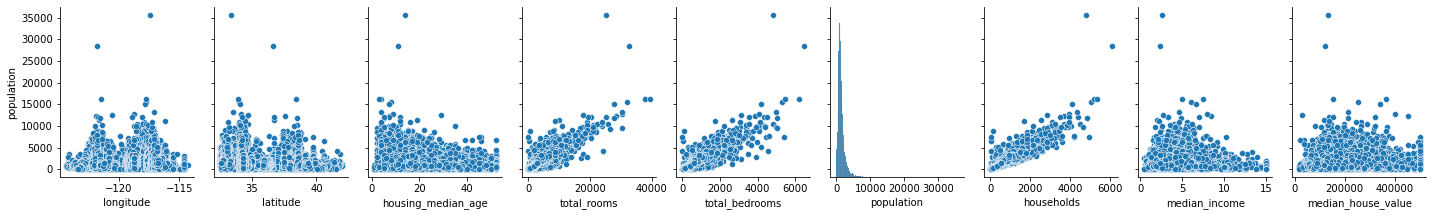

In [5]:
columns_except_target = housing_df.columns[:-1]
target_variable = 'population'

sns.pairplot(
    housing_df,
    x_vars=columns_except_target,
    y_vars=target_variable,
    kind='scatter',
    height=3,  
    aspect=0.75 
)
plt.show()

In [6]:
#In this graphs, we see where and what density the data is.
#In the longitude graph, we see that the density of longitude at 3500 is lower than other value densities.
#In the population graph, we understand that as the value of population increases, its density decreases.

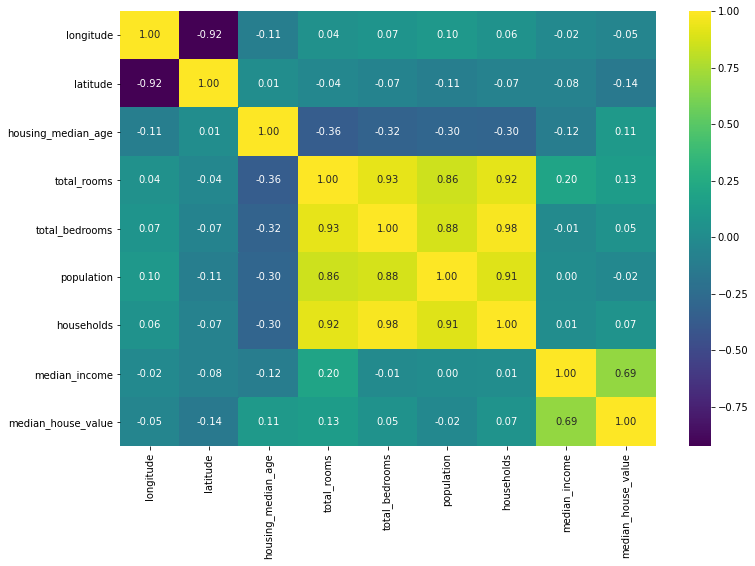

In [7]:
correlation_matrix = housing_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="viridis", fmt=".2f")
plt.show()

In [8]:
#We can see the relationship between the data thanks to the heat map.

<div style="background-color: red; color: white; padding: 10px;">
    <strong>What are these relations? Also, always provide legends to the graphs/plots -2 Pts</strong> 
</div>


## 1.2. Outlier Detection (15 Pts)
* Choose an outlier detection method and apply it to the data.
* Explain your method and why you choose it.

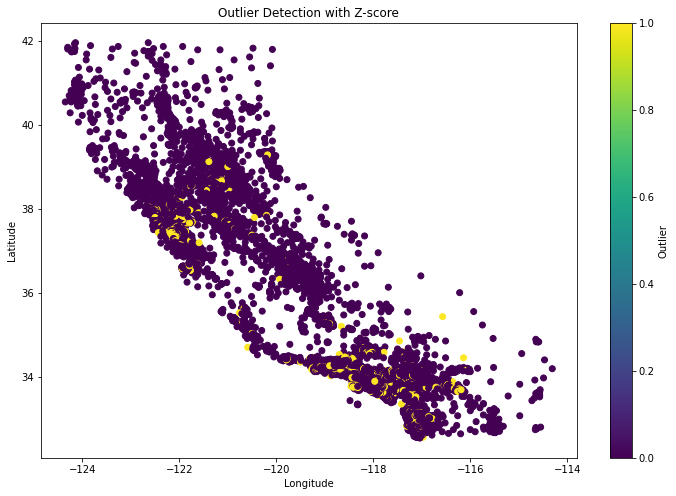

In [9]:
numerical_cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms',
                  'population', 'households', 'median_income', 'median_house_value']
numerical_df = housing_df[numerical_cols]
z_scores = np.abs(stats.zscore(numerical_df))
threshold = 3
outliers = (z_scores > threshold).any(axis=1)
housing_df['is_outlier'] = outliers.astype(int)
outliers_df = housing_df[housing_df['is_outlier'] == 1]
plt.figure(figsize=(12, 8))
plt.scatter(housing_df['longitude'], housing_df['latitude'], c=housing_df['is_outlier'], cmap='viridis')
plt.title('Outlier Detection with Z-score')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Outlier')
plt.show()

In [10]:
"""The code was written using Z-Score because it is an effective method for standardizing data and comparing variables 
with different scales. Additionally, using a threshold of 3 standard deviations is a simple and common technique to identify
and visualize potential outliers."""

'The code was written using Z-Score because it is an effective method for standardizing data and comparing variables \nwith different scales. Additionally, using a threshold of 3 standard deviations is a simple and common technique to identify\nand visualize potential outliers.'

<div style="background-color: red; color: white; padding: 10px;">
    <strong>Why only visualization for longtitude vs latitude? -2 Pts</strong> 
</div>


## 1.3. Outlier Handling (15 Pts)
Try the following methods to handle outliers, creating checkpoints for each. Additionally, visualize the final data distribution after each method to identify any significant changes
1. Keep the dataset as is - take the original checkpoint for baseline comparison.
2. Outlier removal
3. Mean Imputation (Use Mode imputation for categorical variables)
4. Median Imputation (Use Mode imputation for categorical variables)

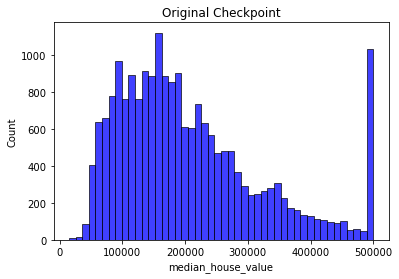

In [11]:
original_checkpoint = housing_df.copy()
plt.figure(figsize=(6, 4))
plt.title('Original Checkpoint')
sns.histplot(original_checkpoint['median_house_value'], kde=False, color='blue')
plt.show()

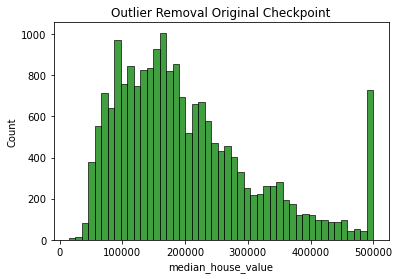

In [12]:
cleaned_df = housing_df[housing_df['is_outlier'] != 1].copy()
plt.figure(figsize=(6, 4))
plt.title('Outlier Removal Original Checkpoint')
sns.histplot(cleaned_df['median_house_value'], kde=False, color='green')
plt.show()

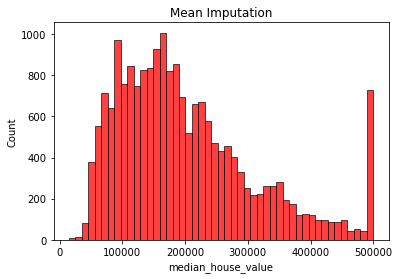

In [13]:
categorical_mode = cleaned_df['ocean_proximity'].mode()[0]
cleaned_df['ocean_proximity'].fillna(categorical_mode, inplace=True)
plt.figure(figsize=(6, 4))
plt.title('Mean Imputation')
sns.histplot(cleaned_df['median_house_value'], kde=False, color='red')
plt.show()

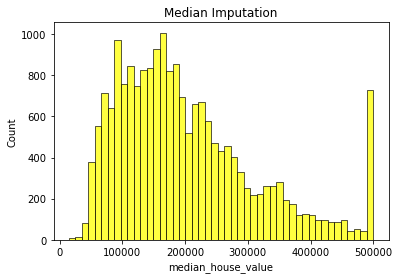

In [14]:
cleaned_df.fillna(cleaned_df.mean(), inplace=True)
plt.figure(figsize=(6, 4))
plt.title('Median Imputation')
sns.histplot(cleaned_df['median_house_value'], kde=False, color='yellow')
plt.show()

<div style="background-color: red; color: white; padding: 10px;">
    <strong>You need to present the distributional change in the features. -7 Pts </strong> 

</div>


## 1.4. Encode the Ordinal Features with Ordinal Encoding (2 Pts)

<div style="background-color: red; color: white; padding: 10px;">
    <strong>No attempt -2</strong>
</div>


## 1.5. Manually shuffle the dataset and split it into training (70%) and testing (30%) sets. Write your own code for shuffling and splitting, avoiding the use of pre-defined functions like train_test_split." (8 Pts)

You  cannot use scikit-learn's shuffle.

In [15]:
shuffled_indices = np.random.permutation(len(cleaned_df))
shuffled_df = cleaned_df.iloc[shuffled_indices].reset_index(drop=True)
split_ratio = 0.7
split_index = int(len(shuffled_df) * split_ratio)
train_set = shuffled_df.iloc[:split_index]
train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,is_outlier
0,-122.44,37.72,48.0,2675.0,585.0,1773.0,540.0,3.9565,268500.0,NEAR BAY,0
1,-118.10,34.06,31.0,2852.0,740.0,3100.0,725.0,2.9524,178800.0,<1H OCEAN,0
2,-122.44,37.67,35.0,1814.0,365.0,1025.0,384.0,4.4250,268400.0,NEAR OCEAN,0
3,-122.77,38.39,35.0,2611.0,475.0,1293.0,463.0,2.7500,197500.0,<1H OCEAN,0
4,-119.56,36.09,14.0,1267.0,290.0,1077.0,279.0,1.8500,52300.0,INLAND,0
...,...,...,...,...,...,...,...,...,...,...,...
13827,-117.11,32.77,50.0,1729.0,355.0,617.0,337.0,3.6705,167000.0,NEAR OCEAN,0
13828,-117.98,33.98,27.0,2275.0,346.0,1039.0,333.0,6.2217,333500.0,<1H OCEAN,0
13829,-118.34,33.87,28.0,4605.0,1188.0,2558.0,1093.0,3.6988,266600.0,<1H OCEAN,0
13830,-118.45,34.00,43.0,1606.0,408.0,862.0,354.0,3.9620,345800.0,<1H OCEAN,0


In [16]:
shuffled_indices = np.random.permutation(len(cleaned_df))
shuffled_df = cleaned_df.iloc[shuffled_indices].reset_index(drop=True)
split_ratio = 0.7
split_index = int(len(shuffled_df) * split_ratio)
test_set = shuffled_df.iloc[split_index:]
test_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,is_outlier
13832,-124.07,40.81,23.0,2103.0,411.0,1019.0,387.0,2.9911,119700.0,NEAR OCEAN,0
13833,-122.27,38.29,36.0,1446.0,306.0,678.0,295.0,2.8409,153000.0,NEAR BAY,0
13834,-118.02,34.13,32.0,3308.0,718.0,1803.0,667.0,3.9464,273600.0,INLAND,0
13835,-119.30,36.34,45.0,3723.0,831.0,2256.0,770.0,1.8299,63100.0,INLAND,0
13836,-117.87,33.74,16.0,1243.0,365.0,1925.0,376.0,2.7632,158900.0,<1H OCEAN,0
...,...,...,...,...,...,...,...,...,...,...,...
19756,-118.15,33.93,25.0,1948.0,433.0,1128.0,429.0,3.7614,255900.0,<1H OCEAN,0
19757,-121.28,38.14,38.0,2803.0,500.0,1223.0,509.0,4.1190,128800.0,INLAND,0
19758,-121.45,36.51,29.0,1045.0,311.0,1245.0,273.0,1.7750,112500.0,<1H OCEAN,0
19759,-122.16,38.02,40.0,1800.0,290.0,761.0,277.0,5.1265,196100.0,NEAR BAY,0


# 2. REGRESSION (50 Pts)
* Target value: median_house_value
* Predictors: The rest

## 2.1. kNN Regression (20 Pts)
* For each version of the dataset (original, outlier-removed, mean-imputed, median-imputed), execute the following steps:"
    * Split the data into train and test sets
    * Create an instance of kNN with a number of neighbors between 1-30, then fit kNN regression model to train data. Predict the test set and calculate the MSE value for each k. Plot the MSE vs k curve to decide on the optimal k. Additionally, report the R-squared value for the optimal k.
* Compare the MSE values for each dataset and comment on the results. Which dataset gives the best result? Why do you think that is?

You can use scikit-learn's KNeighborsRegressor.

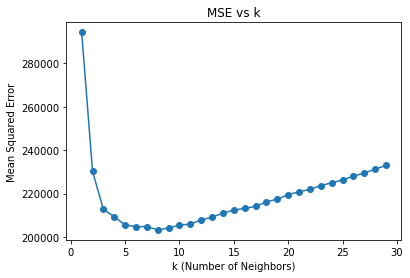

In [17]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
cleaned_df = cleaned_df.drop(columns=['ocean_proximity'])
target_variable = 'population'

def perform_knn_regression(data, target_variable):
    X = data.drop(target_variable, axis=1)
    y = data[target_variable]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    k_values = range(1, 30)
    mse_values = []
    r2_values = []
    for k in k_values:
        knn_model = KNeighborsRegressor(n_neighbors=k)
        knn_model.fit(X_train, y_train)
        y_pred = knn_model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        mse_values.append(mse)
        r2_values.append(r2)
    plt.plot(k_values, mse_values, marker='o')
    plt.title('MSE vs k')
    plt.xlabel('k (Number of Neighbors)')
    plt.ylabel('Mean Squared Error')
    plt.show()
    optimal_k = k_values[mse_values.index(min(mse_values))]
    optimal_r2 = r2_values[k_values.index(optimal_k)]
    return optimal_k, optimal_r2

original_optimal_k, original_optimal_r2 = perform_knn_regression(cleaned_df, target_variable)


<div style="background-color: red; color: white; padding: 10px;">
    <strong>You need to do this for each dataset. Also, you need to provide your comment. -10 Pts</strong> 
</div>


## 2.2. Linear Regression (20 Pts)
* For each version of the dataset (original, outlier removal, mean imputation, median imputation), do the following:
    * Split the data into train and test sets
    * Fit a linear regression model to train data. Predict the test set and calculate the MSE value.

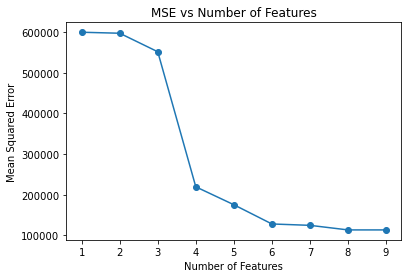

In [18]:
target_variable = 'population'

def perform_linear_regression(data, target_variable):
    X = data.drop(target_variable, axis=1)
    y = data[target_variable]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    mse_values = []
    r2_values = []
    
    for num_features in range(1, X_train.shape[1] + 1):
        linear_model = LinearRegression()
        linear_model.fit(X_train.iloc[:, :num_features], y_train)
        y_pred = linear_model.predict(X_test.iloc[:, :num_features])
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        mse_values.append(mse)
        r2_values.append(r2)
    plt.plot(range(1, X_train.shape[1] + 1), mse_values, marker='o')
    plt.title('MSE vs Number of Features')
    plt.xlabel('Number of Features')
    plt.ylabel('Mean Squared Error')
    plt.show()
    optimal_num_features = mse_values.index(min(mse_values)) + 1
    optimal_r2 = r2_values[optimal_num_features - 1]
    return optimal_num_features, optimal_r2

original_optimal_features, original_optimal_r2 = perform_linear_regression(cleaned_df, target_variable)

<div style="background-color: red; color: white; padding: 10px;">
    <strong>Need to do for each dataset. Why is the graph is for MSE vs number of features? How is the number of features relevant? -15 Pts</strong> 
</div>


## 2.3. Compare the Regression Methods (10 Pts)

Compare and contrast the performance of kNN and Linear Regression models across the different dataset versions (those attained in 1.3.). Discuss the strengths and limitations of each model based on your results

\< double click and insert answer here \>

# PLAGIARISM POLICY

In the interest of maintaining a fair and honest academic environment, this course strictly adheres to a zero-tolerance policy regarding plagiarism. 
Accordingly, all assignments must reflect individual effort and understanding. While abstract discussions with peers about concepts are encouraged, sharing or copying specific solutions, code, or pseudocode is not permitted and will be treated as plagiarism. This policy includes work sourced from the internet, publications, and AI tools like ChatGPT and GitHub Copilot. **MAKE USE OF THEM RESPONSIBLY**. That is, you can utilize them to enhance understanding and support your original work, **not to replace it**. Submitting work that is not entirely your own creation will be regarded as a violation of academic integrity. It is vital to use all resources, including AI, in a manner that supports your educational development without compromising the principles of academic honesty. 

If in doubt, do not hesitate to seek guidance from the course staff - we are here to help, with an aim to foster a learning environment based on trust, respect, and responsibility.

# REFERENCES
[1] Nugent, C. (n.d.). California Housing Prices [Data set]. Kaggle. Retrieved from https://www.kaggle.com/datasets/camnugent/california-housing-prices